# Hubbard model on a honeycomb lattice
---

## Set up the Hamiltonian
---

In [ ]:
# setup scratch dir
from pathlib import Path
from tutorial_utils import run_afqmc, get_scratch_dir

home = Path.home()
scratch_rootdir = home / ".scratch"
scratch_rootdir.mkdir(exist_ok=True)
scratch_dir = get_scratch_dir("honeycomb_hubbard",scratch_rootdir)

computing and storing 1th-nearest neighbors
Computing distance matrix of lattice
Reading lattice site positions from Lattice
computing and storing 1th-nearest image neighbors


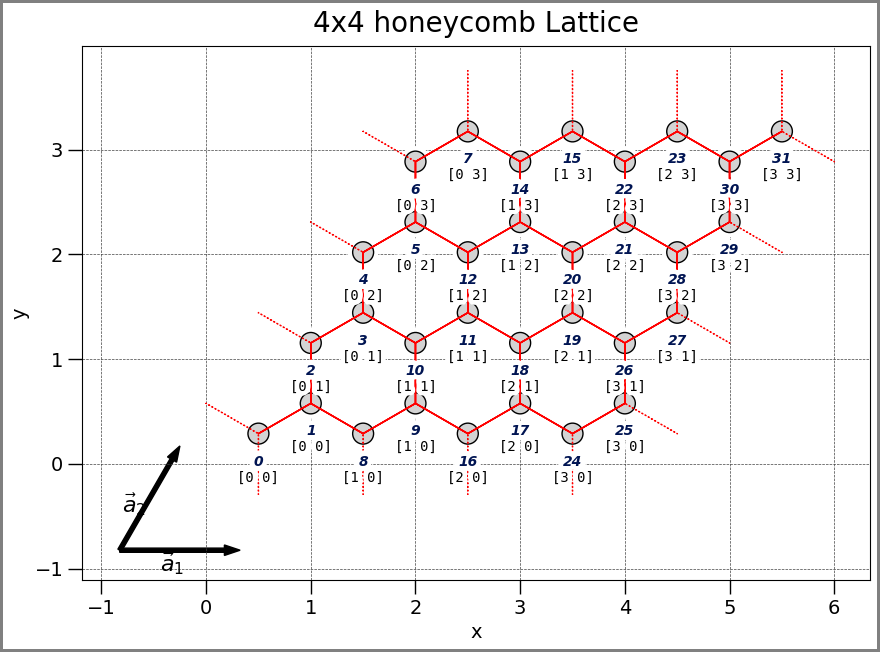

running build step nth_neighbor_hopping((1.0,))
Using same twists for up and down spins
running build step onsite_hubbard((6.0,))
Building Hubbard U term with U=6.0
Building onsite hubbard with positive U values: 6.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2


In [ ]:
# set up Hamiltonain
# setup the Hamiltonian
import numpy as np

from afqmctools.systems.lattice import get_lattice
from afqmctools.utils.visualize import plot_lattice
from afqmctools.hamiltonian.model.director import HamiltonianDirector
import afqmctools.utils.io as io

lattice = get_lattice(
    params=dict(
        L1 = 4,
        L2 = 4,
        boundary1 = "pbc",
        boundary2 = "pbc",
        type = "honeycomb"
    )
)

# plot the lattice for reality checks!
plot_lattice(lattice)

# define Hamiltonian parameters
hamiltonian_params = {
    'U': 6.0
}

params = {
    'hamiltonian': hamiltonian_params
}

# make the Hamiltonian
hamiltonian = HamiltonianDirector(
    source=params,
    lattice=lattice
).build()

# save for AFQMC
io.write_model_hamiltonian(hamiltonian,fname=scratch_dir/"afqmc.h5")

In [ ]:
# run autoHF and save wavefunction as trial wavefunction
from autohf import lattice_hf
from autohf.hamiltonian import AutoHFHamiltonian
from afqmctools.inputs.from_autohf import autohf_to_afqmc

# Typically, we want to use a Ueff to generate a trial wavefunction
#    since HF's critical U is lower than the correct critical U
Ueff = 3.0

# define effective Hamiltonian parameters
hamiltonian_params = {
    'U': Ueff
}

params = {
    'hamiltonian': hamiltonian_params
}

# make the Hamiltonian
effective_hamiltonian = HamiltonianDirector(
    source=params,
    lattice=lattice
).build()

# convert afqmctools Hamitlonian to AutoHFHamiltonian
autohf_hamiltonian = AutoHFHamiltonian(effective_hamiltonian)

# set the number of electrons!!
nelec=(16-1,16-1)

settings = dict(
    ansatz = 'SD_ROT',
    numSteps = 100,
    nelec = nelec,
    numTrials = 100,
    seed = 42
)

results = lattice_hf(hamiltonian=autohf_hamiltonian,settings=settings)

autohf_to_afqmc(results,output_fname=scratch_dir/"afqmc.h5")

running build step nth_neighbor_hopping((1.0,))
Using same twists for up and down spins
running build step onsite_hubbard((3.0,))
Building Hubbard U term with U=3.0
Building onsite hubbard with positive U values: 3.0
Combining terms of the same type
Combining Hubbard U, U1, and U2 terms where possible
Max spin symmetry is  2
Reading hopping from spin sector 0
Reading hopping from spin sector 1
Added unique T terms: [array([-1.]), array([-1.])]
Added unique U terms: [3.]

    -----------------------
    - ╔═╗ ------- ╖ ╓╔═╕ --
    - ╠═╣ ╖╖╒╦╕╔╗ ╠═╣╠╕ ---
    - ╜ ╙ ╚╝ ╜ ╚╝ ╜ ╙╨ ----
    -----------------------
    

 ===== AutoHF Settings ===== 

        noncollinear                                            False
        gpu                                                     False
        approx_expm                                             False
        force_complex                                           False
        ansatz                                                 SD_R

/mnt/ceph/users/beskridge/software/AuxiliaryFields/utils/afqmctools/wavefunction/common.py:166: UserWarning: Using UHF Slater determinant for initial Walkers with a Collinear Trial Wavefunction. This can lead to very slow equilibration in AFQMC calculations. using ROHF Slater determinants for intiail Walkers is recommended.
  warn(


## Write input file
---

For more information about the input file, see the [Understanding the input file](../../../tutorials/models/02_understanding_the_input_file/02_understanding_the_input_file.html) tutorial.


In [ ]:
from afqmctools.inputs.from_hdf import write_json

# write input file
afqmc_execution_options = {
    "timestep": 0.01,
    "steps": 10000,
    "accumlate_interval": 10,           # in units of steps
    "measure_interval": 10,             # in units of steps
    "population_control_interval" : 10, # in units of steps
    "walker_ortho_interval" : 10 ,      # in units of steps
    "n_walkers_per_mpi_task": 100,
    "seed" : 42
}

write_json(
    scratch_dir/ "afqmc.json",
    fwfn0=scratch_dir / "afqmc.h5",
    exec_opts=afqmc_execution_options
)

## run AFQMC
---

In [ ]:
# run AuxiliaryFields
run_afqmc(
    run_dir=scratch_dir,
    run_mode="local_cpu",
    input_file="afqmc.json",
    np=16,             # number of MPI tasks
    output_file=None   # optionally direct output to file instead of here
)

Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
   _____               .__.__  .__                      ___________.__       .__       .___     
  /  _  \  __ _____  __|__|  | |__|____ _______ ___.__. \_   _____/|__| ____ |  |    __| _/______
 /  /_\  \|  |  \  \/  /  |  | |  \__  \_  __ <   |  |  |    __)  |  |/ __ \|  |   / __ |/  ___/
/    |    \  |  />    <|  |  |_|  |/ __ \|  | \/\___  |  |     \   |  \  ___/|  |__/ /_/ |\___ \ 
\____|__  /____//__/\_ \__|____/__(____  /__|   / ____|  \___  /   |__|\___  >____/\____ /____  >
        \/            \/               \/       \/           \/            \/           \/    \/   
=====================================================================

117.21494658302981

## Analyze the results
---



====== [analyze_scalar_data Settings] ======

[+] fname            = /mnt/home/beskridge/.scratch/honeycomb_hubbard/qmc.s000.scalar.dat
[+] shebang          = #               
[+] xaxis            = time            
[+] nequil           = 5               
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] list             = False           
[+] trace            = True            
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] savefig          = None            
[+] ndiscard         = None            
[+] return_data      = False           
[+] autocorr         = None            
[+] verbose          = True            
[+] dump_avail_columns = False           

AFQMC Energy   -21.576441 +/-   0.011367 8.99  5.0/100.0


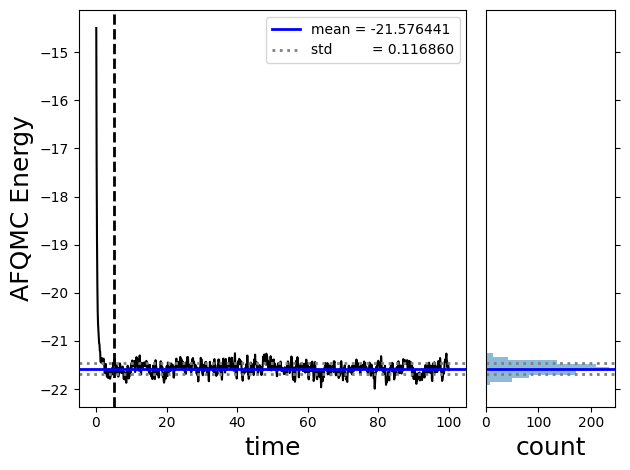

In [ ]:
# analyze results
from stats.scalar_dat import analyze_scalar_data

_ = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    xaxis = "time",
    nequil = 5,
    trace = True
))